### Fitting the psychometric function
Run both cells top to bottom. Edit the `👈` value and re-run.

true:  mean=0, sd=0.1
fit:   mean=0.026, sd=0.109


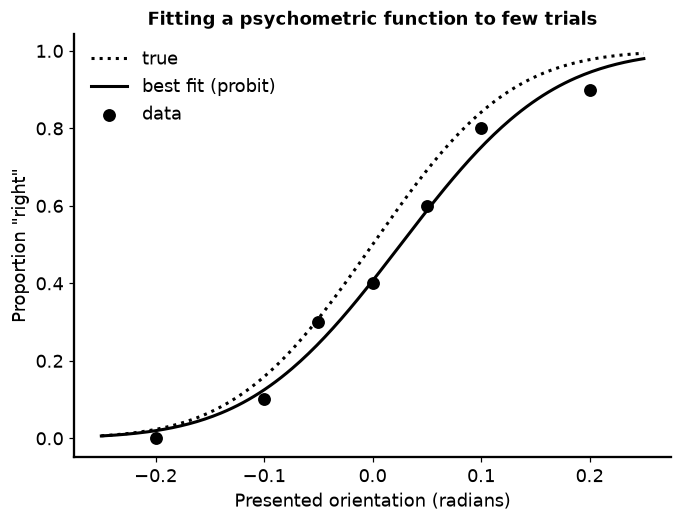

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})

from scipy.optimize import minimize

# --- the psychometric function and the error we minimise ---
def probit_pf(p, x):
    return norm.cdf(x, p[0], p[1])              # p = [mean, sd]

def neg_log_lik(p, pf, x, n_right, n_total):
    pp = np.clip(pf(p, x), 1e-6, 1 - 1e-6)
    return -np.sum(n_right * np.log(pp) + (n_total - n_right) * np.log(1 - pp))

# --- simulate an observer with only a few trials ---
signal_strengths = np.array([-0.2,-0.1,-0.05,0,0.05,0.1,0.2])
noise_sd  = 0.1
ntrials   = 10      # 👈 trials per signal strength
criterion = 0

rng = np.random.default_rng()
samples = rng.standard_normal((ntrials, signal_strengths.size)) * noise_sd + signal_strengths
proportion_right = (samples > criterion).mean(axis=0)
n_right = proportion_right * ntrials
n_total = np.full(signal_strengths.size, ntrials)

# --- find the best-fitting mean and sd ---
res = minimize(lambda p: neg_log_lik(p, probit_pf, signal_strengths, n_right, n_total),
               x0=[criterion, noise_sd], method="Nelder-Mead")
fit_mean, fit_sd = res.x
print(f"true:  mean={criterion}, sd={noise_sd}")
print(f"fit:   mean={fit_mean:.3f}, sd={fit_sd:.3f}")

xs = np.linspace(-0.25, 0.25, 200)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(xs, norm.cdf(xs, criterion, noise_sd), "k:", lw=2, label="true")
ax.plot(xs, probit_pf([fit_mean, fit_sd], xs), "k", lw=2, label="best fit (probit)")
ax.scatter(signal_strengths, proportion_right, 55, color="k", zorder=3, label="data")
ax.set(xlabel="Presented orientation (radians)", ylabel='Proportion "right"',
       title="Fitting a psychometric function to few trials")
ax.legend()
plt.show()


negative log likelihood -- probit: 31.61   logistic: 31.65


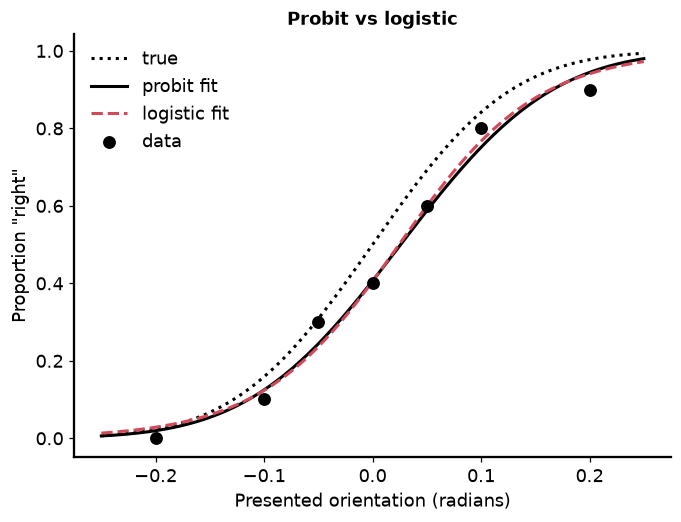

In [2]:
# the logistic is another popular psychometric function (similar shape, different basis)
def logistic_pf(p, x):
    return 1.0 / (1.0 + np.exp(-p[1] * (x - p[0])))   # p = [midpoint, slope]

res_log = minimize(lambda p: neg_log_lik(p, logistic_pf, signal_strengths, n_right, n_total),
                   x0=[0.0, 1.0 / noise_sd], method="Nelder-Mead")

nll_probit  = neg_log_lik([fit_mean, fit_sd], probit_pf, signal_strengths, n_right, n_total)
nll_logist  = neg_log_lik(res_log.x, logistic_pf, signal_strengths, n_right, n_total)
print(f"negative log likelihood -- probit: {nll_probit:.2f}   logistic: {nll_logist:.2f}")

xs = np.linspace(-0.25, 0.25, 200)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(xs, norm.cdf(xs, criterion, noise_sd), "k:", lw=2, label="true")
ax.plot(xs, probit_pf([fit_mean, fit_sd], xs), "k", lw=2, label="probit fit")
ax.plot(xs, logistic_pf(res_log.x, xs), color="#d1495b", ls="--", lw=2, label="logistic fit")
ax.scatter(signal_strengths, proportion_right, 55, color="k", zorder=3, label="data")
ax.set(xlabel="Presented orientation (radians)", ylabel='Proportion "right"',
       title="Probit vs logistic")
ax.legend()
plt.show()
